In [32]:
import pandas as pd
import json
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [33]:
with open("queries_and_videos.json", "r") as f:
    queries_and_videos = json.load(f)

In [34]:
queries = [q for cat in queries_and_videos for q in queries_and_videos[cat]]
len(queries)

93

In [35]:
associated_videos = [v for cat in queries_and_videos for q, v in queries_and_videos[cat].items()]
associated_videos_flat = [v for video_list in associated_videos for v in video_list]
len(set(associated_videos_flat))

2667

In [36]:
queries_videos_df = pd.concat([pd.DataFrame({"queries": list(queries_and_videos[cat].keys()), "videos": list(np.array(q) for q in queries_and_videos[cat].values()), "category": [cat for _ in range(len(queries_and_videos[cat].keys()))]}) for cat in queries_and_videos])
queries_videos_df["nb_videos"] = queries_videos_df["videos"].apply(lambda d: len(d))
queries_videos_df["nb_videos"].describe()

count      93.000000
mean       73.010753
std       190.897053
min         0.000000
25%         5.000000
50%        18.000000
75%        55.000000
max      1338.000000
Name: nb_videos, dtype: float64

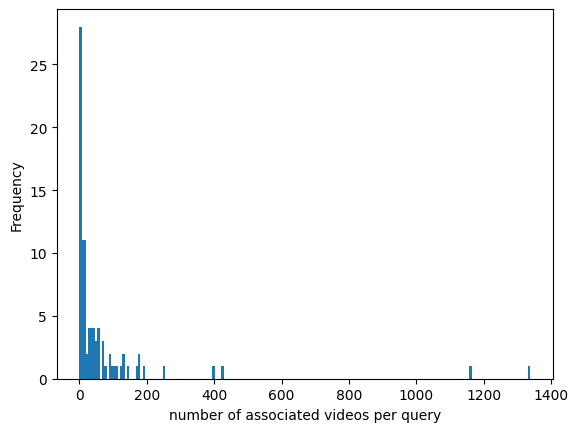

10 queries with no video associated to them


In [37]:
queries_videos_df["nb_videos"].plot(kind="hist", bins=200)
plt.xlabel("number of associated videos per query")
plt.show()
print(len(queries_videos_df[queries_videos_df["nb_videos"] == 0]), "queries with no video associated to them")

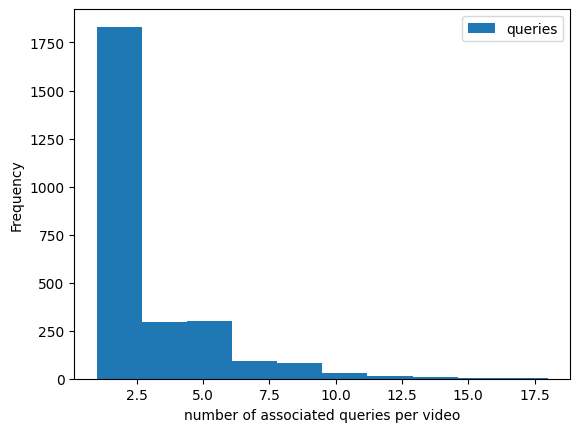

In [42]:
queries_videos_df.explode("videos").groupby("videos").agg({"queries": pd.Series.nunique}).plot(kind="hist")
plt.xlabel("number of associated queries per video")
plt.show()

## Remaining videos

In [23]:
annotation_paths = list(Path("/media/EVO870/datasets/prompting-mammalps/annotations").rglob("*.json"))
all_video_ids = [f.stem for f in annotation_paths]
remaining_ids = set(all_video_ids) - set(associated_videos_flat)

len(remaining_ids)

97